<a href="https://colab.research.google.com/github/vardefenil/ai-resume-analyzer/blob/main/Copy_of_Practical_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                                  PRACTICAL-3

Aim: - Implement Logistic Regression in R or Python.

   sepal_length  sepal_width  petal_length  petal_width species  Target
0           5.1          3.5           1.4          0.2  setosa       1
1           4.9          3.0           1.4          0.2  setosa       1
2           4.7          3.2           1.3          0.2  setosa       1
3           4.6          3.1           1.5          0.2  setosa       1
4           5.0          3.6           1.4          0.2  setosa       1
Accuracy WITHOUT Scaling: 1.0
Accuracy WITH Scaling: 1.0
   C Value  Accuracy
0    0.001  0.605263
1    0.010  0.631579
2    0.100  1.000000
3    1.000  1.000000
4   10.000  1.000000
5  100.000  1.000000


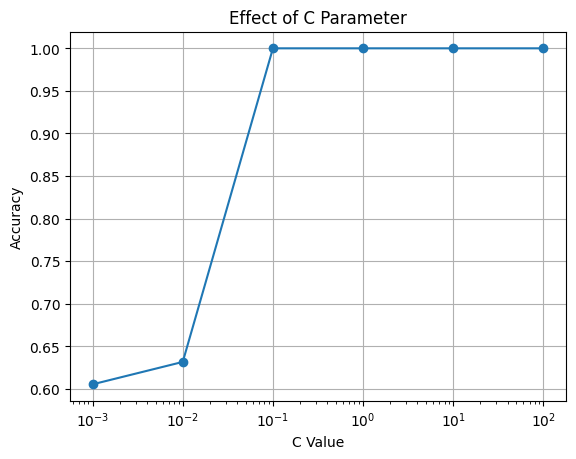

    Model  Accuracy
0  No Reg       1.0
1      L1       1.0
2      L2       1.0


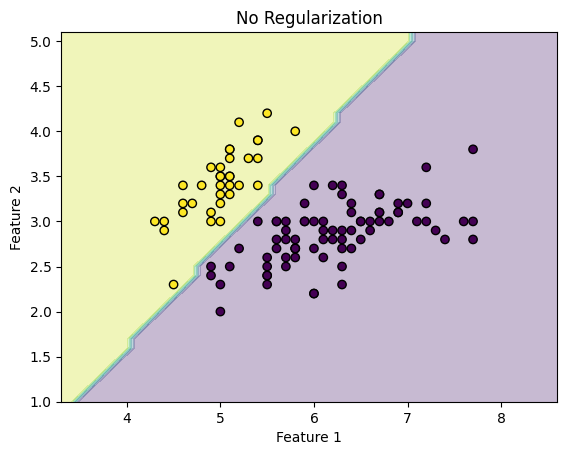

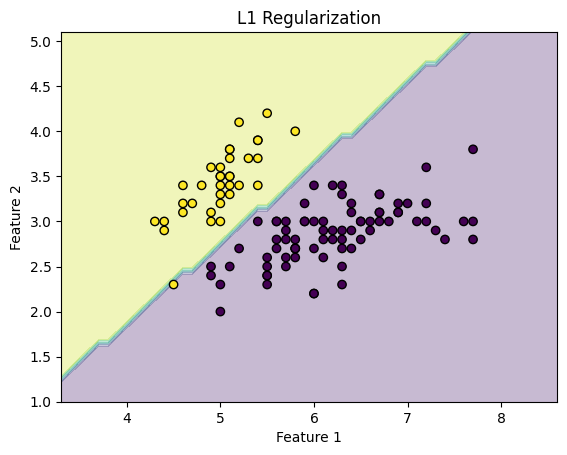

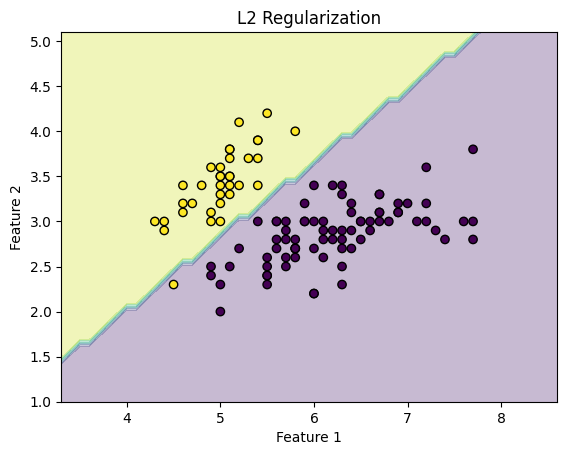

    Feature     No Reg       L1        L2
0  Feature1 -33.537656 -3.99502 -2.987483
1  Feature2  15.785551  2.41325  1.939896
Polynomial Accuracy: 1.0


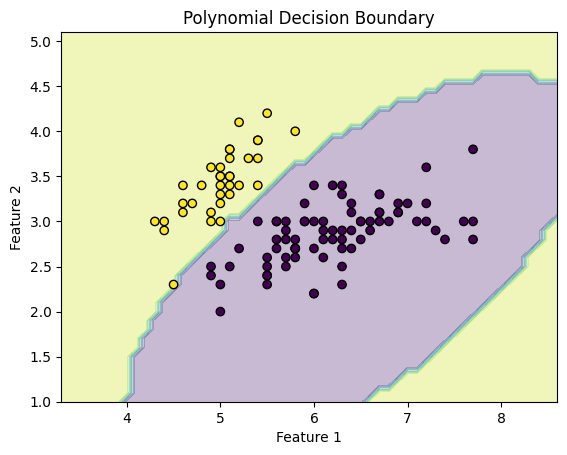

Conclusion: Logistic Regression works well and polynomial gives better accuracy.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")

# Convert to binary classification
df['Target'] = df['species'].apply(lambda x: 1 if x == 'setosa' else 0)

# Select features and target
X = df[['sepal_length', 'sepal_width']].values
y = df['Target'].values

print(df.head())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Without scaling
model_no_scaling = LogisticRegression()
model_no_scaling.fit(X_train, y_train)

y_pred_no_scaling = model_no_scaling.predict(X_test)
print("Accuracy WITHOUT Scaling:", accuracy_score(y_test, y_pred_no_scaling))

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_with_scaling = LogisticRegression()
model_with_scaling.fit(X_train_scaled, y_train)

y_pred_with_scaling = model_with_scaling.predict(X_test_scaled)
print("Accuracy WITH Scaling:", accuracy_score(y_test, y_pred_with_scaling))

# Effect of C parameter
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
accuracies = []

for C in C_values:
    model = LogisticRegression(C=C)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

results = pd.DataFrame({
    "C Value": C_values,
    "Accuracy": accuracies
})

print(results)

plt.figure()
plt.plot(C_values, accuracies, marker='o')
plt.xscale("log")
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("Effect of C Parameter")
plt.grid(True)
plt.show()

# Regularization
model_none = LogisticRegression(penalty=None)
model_none.fit(X_train_scaled, y_train)

model_l1 = LogisticRegression(penalty="l1", solver="liblinear")
model_l1.fit(X_train_scaled, y_train)

model_l2 = LogisticRegression(penalty="l2")
model_l2.fit(X_train_scaled, y_train)

print(pd.DataFrame({
    "Model": ["No Reg", "L1", "L2"],
    "Accuracy": [
        accuracy_score(y_test, model_none.predict(X_test_scaled)),
        accuracy_score(y_test, model_l1.predict(X_test_scaled)),
        accuracy_score(y_test, model_l2.predict(X_test_scaled))
    ]
}))

# Decision boundary function
def plot_boundary(X, y, model, scaler, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.1),
        np.arange(y_min, y_max, 0.1)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)

    Z = model.predict(grid_scaled)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_boundary(X_train, y_train, model_none, scaler, "No Regularization")
plot_boundary(X_train, y_train, model_l1, scaler, "L1 Regularization")
plot_boundary(X_train, y_train, model_l2, scaler, "L2 Regularization")

# Coefficients
coef_df = pd.DataFrame({
    "Feature": ["Feature1", "Feature2"],
    "No Reg": model_none.coef_[0],
    "L1": model_l1.coef_[0],
    "L2": model_l2.coef_[0]
})

print(coef_df)

# Polynomial logistic regression
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LogisticRegression(max_iter=1000)
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)
print("Polynomial Accuracy:", accuracy_score(y_test, y_pred_poly))

# Polynomial decision boundary
xx, yy = np.meshgrid(
    np.arange(X_train[:, 0].min()-1, X_train[:, 0].max()+1, 0.1),
    np.arange(X_train[:, 1].min()-1, X_train[:, 1].max()+1, 0.1)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)
grid_poly = poly.transform(grid_scaled)

Z = poly_model.predict(grid_poly)
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k')
plt.title("Polynomial Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Conclusion
print("Conclusion: Logistic Regression works well and polynomial gives better accuracy.")